In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()


Saving aa_va_flights_oct_nov_dec_2025_clean.csv to aa_va_flights_oct_nov_dec_2025_clean.csv


In [3]:
df = pd.read_csv("aa_va_flights_oct_nov_dec_2025_clean.csv")

df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,tail_num,op_carrier_fl_num,origin,...,nas_delay,security_delay,late_aircraft_delay,source_file,route,dep_hour,block_time_error,underblocked,late_arrival,is_weekend
0,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,DCA,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,DCA-PBI,8,-7.0,0,0,0
1,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,1394,PBI,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,PBI-DCA,12,6.0,1,0,0
2,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,2040,DCA,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,DCA-CLT,15,6.0,1,0,0
3,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N109UW,527,CLT,...,NaN,NaN,NaN,T_ONTIME_REPORTING OCT 2025.csv,CLT-DCA,18,-5.0,0,0,0
4,2025,4,10,1,3,10/1/2025 12:00:00 AM,AA,N114UW,1269,CLT,...,0.0,0.0,0.0,T_ONTIME_REPORTING OCT 2025.csv,CLT-DCA,21,-17.0,0,1,0


In [4]:
df.columns

Index(['year', 'quarter', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'tail_num', 'op_carrier_fl_num', 'origin', 'dest',
       'crs_dep_time', 'dep_time', 'dep_delay', 'dep_delay_new', 'taxi_out',
       'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'arr_delay_new',
       'arr_del15', 'cancelled', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay',
       'source_file', 'route', 'dep_hour', 'block_time_error', 'underblocked',
       'late_arrival', 'is_weekend'],
      dtype='object')

In [5]:
target = "actual_elapsed_time"
baseline_col = "crs_elapsed_time"

df_model = df.copy()

df_model = df_model.dropna(subset=[target, baseline_col])

In [6]:
features = [
    "origin",
    "dest",
    "route",
    "month",
    "day_of_week",
    "is_weekend",
    "dep_hour",
    "crs_elapsed_time",
    "distance"
]

X = df_model[features]
y = df_model[target]

Train: October and November 2025
Test: December 2025

In [7]:
train_df = df_model[df_model["month"].isin([10, 11])]
test_df = df_model[df_model["month"] == 12]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

Evaluating baseline first

In [8]:
baseline_pred = X_test["crs_elapsed_time"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

baseline_results = {
    "Model": "Baseline: Scheduled Block Time",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}

baseline_results

{'Model': 'Baseline: Scheduled Block Time',
 'MAE': 12.473908413205537,
 'RMSE': np.float64(16.35459701278143),
 'R2': 0.9190658037423455}

RESULT TABLE

In [12]:
import pandas as pd

results = []

results.append({
    "Model": "Baseline: Scheduled Block Time",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Baseline: Scheduled Block Time,12.473908,16.354597,0.919066


Linear Regression

In [13]:
categorical_features = [
    "origin",
    "dest",
    "route"
]

numeric_features = [
    "month",
    "day_of_week",
    "is_weekend",
    "dep_hour",
    "crs_elapsed_time",
    "distance"
]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [15]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['origin', 'dest', 'route']),
                                                 ('num', StandardScaler(),
                                                  ['month', 'day_of_week',
                                                   'is_weekend', 'dep_hour',
                                                   'crs_elapsed_time',
                                                   'distance'])])),
                ('model', LinearRegression())])

In [18]:
linear_pred = linear_model.predict(X_test)

In [19]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

linear_results = {
    "Model": "Linear Regression",
    "MAE": linear_mae,
    "RMSE": linear_rmse,
    "R2": linear_r2
}

linear_results

{'Model': 'Linear Regression',
 'MAE': 10.922607462293456,
 'RMSE': np.float64(15.358652282585798),
 'R2': 0.9286229524376697}

In [20]:
results.append(linear_results)

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,MAE,RMSE,R2
0,Baseline: Scheduled Block Time,12.474,16.355,0.919
1,Linear Regression,10.923,15.359,0.929


Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [23]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['origin', 'dest', 'route']),
                                                 ('num', StandardScaler(),
                                                  ['month', 'day_of_week',
                                                   'is_weekend', 'dep_hour',
                                                   'crs_elapsed_time',
                                                   'distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=5,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [24]:
rf_pred = rf_model.predict(X_test)

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

rf_results = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

rf_results

{'Model': 'Random Forest',
 'MAE': 10.89451670078413,
 'RMSE': np.float64(15.493504779929108),
 'R2': 0.9273640360388722}

In [26]:
results.append(rf_results)

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,MAE,RMSE,R2
0,Baseline: Scheduled Block Time,12.474,16.355,0.919
1,Linear Regression,10.923,15.359,0.929
2,Random Forest,10.895,15.494,0.927


GRADIENT BOOSTING RESGRESSOR

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

In [28]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

In [29]:
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['origin', 'dest', 'route']),
                                                 ('num', StandardScaler(),
                                                  ['month', 'day_of_week',
                                                   'is_weekend', 'dep_hour',
                                                   'crs_elapsed_time',
                                                   'distance'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05,
                                           min_samples_leaf=5, n_estimators=300,
                                           random_state=42))])

In [30]:
gb_pred = gb_model.predict(X_test)

In [31]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

gb_results = {
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2
}

gb_results

{'Model': 'Gradient Boosting',
 'MAE': 10.81908099707659,
 'RMSE': np.float64(15.343473123511775),
 'R2': 0.9287639684784605}

In [32]:
results.append(gb_results)

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,MAE,RMSE,R2
0,Baseline: Scheduled Block Time,12.474,16.355,0.919
1,Linear Regression,10.923,15.359,0.929
2,Random Forest,10.895,15.494,0.927
3,Gradient Boosting,10.819,15.343,0.929


In [33]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="MAE").reset_index(drop=True)

results_df.round(3)

,Model,MAE,RMSE,R2
0,Gradient Boosting,10.819,15.343,0.929
1,Random Forest,10.895,15.494,0.927
2,Linear Regression,10.923,15.359,0.929
3,Baseline: Scheduled Block Time,12.474,16.355,0.919


In [34]:
best_model = results_df.iloc[0]

best_model

,0
Model,Gradient Boosting
MAE,10.819081
RMSE,15.343473
R2,0.928764


Route-level prediction error analysis

In [35]:
route_error_df = X_test.copy()

route_error_df["actual_elapsed_time"] = y_test.values
route_error_df["baseline_pred"] = baseline_pred.values
route_error_df["linear_pred"] = linear_pred
route_error_df["rf_pred"] = rf_pred
route_error_df["gb_pred"] = gb_pred

route_error_df.head()

,origin,dest,route,month,day_of_week,is_weekend,dep_hour,crs_elapsed_time,distance,actual_elapsed_time,baseline_pred,linear_pred,rf_pred,gb_pred
12114,DCA,CLT,DCA-CLT,12,1,0,8,98.0,331.0,96.0,98.0,88.942281,94.222622,91.023818
12115,CLT,RIC,CLT-RIC,12,1,0,13,70.0,257.0,60.0,70.0,65.496450,64.947464,67.241014
12116,RIC,CLT,RIC-CLT,12,1,0,14,86.0,257.0,74.0,86.0,76.822818,79.347966,77.367970
12117,CLT,RIC,CLT-RIC,12,1,0,18,71.0,257.0,57.0,71.0,66.491896,67.311946,69.405592
12118,RIC,CLT,RIC-CLT,12,1,0,20,85.0,257.0,81.0,85.0,76.777749,80.041727,78.494836


In [36]:
route_error_df["baseline_error"] = route_error_df["actual_elapsed_time"] - route_error_df["baseline_pred"]
route_error_df["linear_error"] = route_error_df["actual_elapsed_time"] - route_error_df["linear_pred"]
route_error_df["rf_error"] = route_error_df["actual_elapsed_time"] - route_error_df["rf_pred"]
route_error_df["gb_error"] = route_error_df["actual_elapsed_time"] - route_error_df["gb_pred"]

route_error_df["gb_abs_error"] = route_error_df["gb_error"].abs()

route_error_df.head()

,origin,dest,route,month,day_of_week,is_weekend,dep_hour,crs_elapsed_time,distance,actual_elapsed_time,baseline_pred,linear_pred,rf_pred,gb_pred,baseline_error,linear_error,rf_error,gb_error,gb_abs_error
12114,DCA,CLT,DCA-CLT,12,1,0,8,98.0,331.0,96.0,98.0,88.942281,94.222622,91.023818,-2.0,7.057719,1.777378,4.976182,4.976182
12115,CLT,RIC,CLT-RIC,12,1,0,13,70.0,257.0,60.0,70.0,65.496450,64.947464,67.241014,-10.0,-5.496450,-4.947464,-7.241014,7.241014
12116,RIC,CLT,RIC-CLT,12,1,0,14,86.0,257.0,74.0,86.0,76.822818,79.347966,77.367970,-12.0,-2.822818,-5.347966,-3.367970,3.367970
12117,CLT,RIC,CLT-RIC,12,1,0,18,71.0,257.0,57.0,71.0,66.491896,67.311946,69.405592,-14.0,-9.491896,-10.311946,-12.405592,12.405592
12118,RIC,CLT,RIC-CLT,12,1,0,20,85.0,257.0,81.0,85.0,76.777749,80.041727,78.494836,-4.0,4.222251,0.958273,2.505164,2.505164


In [37]:
route_level_error = (
    route_error_df
    .groupby("route")
    .agg(
        flights=("actual_elapsed_time", "count"),
        avg_actual_elapsed_time=("actual_elapsed_time", "mean"),
        avg_scheduled_time=("crs_elapsed_time", "mean"),
        avg_gb_prediction=("gb_pred", "mean"),
        mae_gb=("gb_abs_error", "mean"),
        avg_signed_error_gb=("gb_error", "mean")
    )
    .reset_index()
)

route_level_error = route_level_error.sort_values(by="mae_gb", ascending=False)

route_level_error.round(2)

,route,flights,avg_actual_elapsed_time,avg_scheduled_time,avg_gb_prediction,mae_gb,avg_signed_error_gb
65,SYR-DCA,21,98.19,89.57,82.40,21.39,15.79
33,DCA-VPS,30,157.80,160.60,151.76,16.93,6.04
18,DCA-MCI,1,178.00,171.00,161.17,16.83,16.83
40,IAD-DFW,60,211.88,224.53,206.68,16.16,5.21
60,RIC-DFW,85,217.46,216.78,215.28,15.90,2.18
...,...,...,...,...,...,...,...
58,RDU-DCA,13,61.92,67.00,66.81,6.78,-4.88
6,CLT-ORF,71,67.44,74.39,68.00,6.66,-0.56
5,CLT-IAD,36,72.44,84.00,76.95,6.39,-4.50
48,MIA-RIC,44,141.45,145.64,139.95,6.27,1.51


In [38]:
route_level_error_filtered = route_level_error[route_level_error["flights"] >= 5]

route_level_error_filtered.round(2)

,route,flights,avg_actual_elapsed_time,avg_scheduled_time,avg_gb_prediction,mae_gb,avg_signed_error_gb
65,SYR-DCA,21,98.19,89.57,82.40,21.39,15.79
33,DCA-VPS,30,157.80,160.60,151.76,16.93,6.04
40,IAD-DFW,60,211.88,224.53,206.68,16.16,5.21
60,RIC-DFW,85,217.46,216.78,215.28,15.90,2.18
13,DCA-DFW,272,215.54,221.96,213.46,15.43,2.08
...,...,...,...,...,...,...,...
0,BDL-DCA,12,85.83,89.00,82.29,6.84,3.55
58,RDU-DCA,13,61.92,67.00,66.81,6.78,-4.88
6,CLT-ORF,71,67.44,74.39,68.00,6.66,-0.56
5,CLT-IAD,36,72.44,84.00,76.95,6.39,-4.50


In [39]:
worst_routes = route_level_error_filtered.sort_values(by="mae_gb", ascending=False).head(10)

worst_routes.round(2)

,route,flights,avg_actual_elapsed_time,avg_scheduled_time,avg_gb_prediction,mae_gb,avg_signed_error_gb
65,SYR-DCA,21,98.19,89.57,82.40,21.39,15.79
33,DCA-VPS,30,157.80,160.60,151.76,16.93,6.04
40,IAD-DFW,60,211.88,224.53,206.68,16.16,5.21
60,RIC-DFW,85,217.46,216.78,215.28,15.90,2.18
13,DCA-DFW,272,215.54,221.96,213.46,15.43,2.08
29,DCA-SAT,22,226.64,234.18,219.63,15.42,7.01
61,RIC-MIA,45,150.80,157.11,148.90,14.99,1.90
30,DCA-SRQ,29,157.59,158.14,150.38,14.86,7.21
17,DCA-LAX,60,349.18,359.83,347.12,14.43,2.07
23,DCA-PBI,116,153.16,158.51,150.16,14.11,3.00


In [40]:
best_routes = route_level_error_filtered.sort_values(by="mae_gb", ascending=True).head(10)

best_routes.round(2)

,route,flights,avg_actual_elapsed_time,avg_scheduled_time,avg_gb_prediction,mae_gb,avg_signed_error_gb
48,MIA-RIC,44,141.45,145.64,139.95,6.27,1.51
5,CLT-IAD,36,72.44,84.00,76.95,6.39,-4.50
6,CLT-ORF,71,67.44,74.39,68.00,6.66,-0.56
58,RDU-DCA,13,61.92,67.00,66.81,6.78,-4.88
0,BDL-DCA,12,85.83,89.00,82.29,6.84,3.55
7,CLT-RIC,167,67.30,74.44,69.44,7.82,-2.14
66,TPA-DCA,131,129.02,133.63,131.58,7.85,-2.57
31,DCA-SYR,21,78.95,85.71,77.01,8.02,1.94
46,MIA-DCA,291,149.29,154.49,150.93,8.09,-1.65
38,FLL-DCA,71,145.62,151.01,147.26,8.30,-1.64


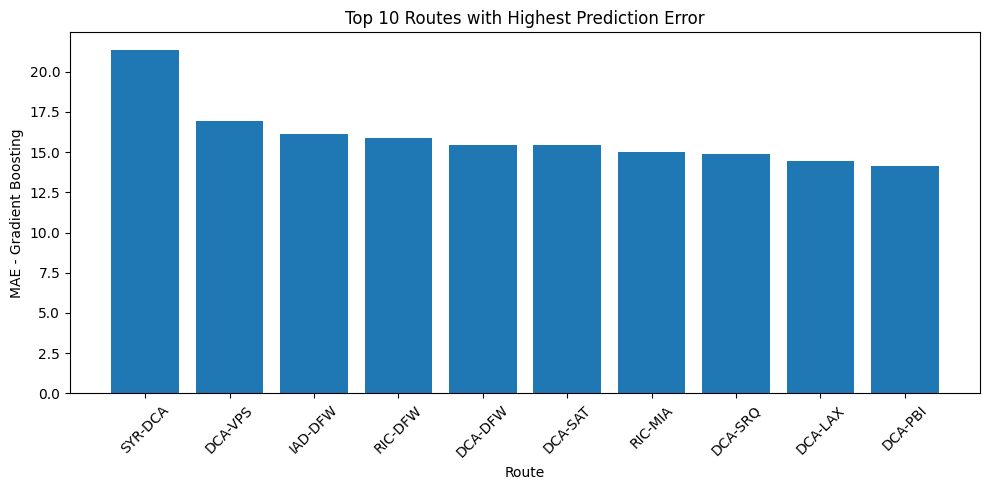

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(worst_routes["route"], worst_routes["mae_gb"])
plt.xlabel("Route")
plt.ylabel("MAE - Gradient Boosting")
plt.title("Top 10 Routes with Highest Prediction Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
route_level_error_filtered.round(2)

,route,flights,avg_actual_elapsed_time,avg_scheduled_time,avg_gb_prediction,mae_gb,avg_signed_error_gb
65,SYR-DCA,21,98.19,89.57,82.40,21.39,15.79
33,DCA-VPS,30,157.80,160.60,151.76,16.93,6.04
40,IAD-DFW,60,211.88,224.53,206.68,16.16,5.21
60,RIC-DFW,85,217.46,216.78,215.28,15.90,2.18
13,DCA-DFW,272,215.54,221.96,213.46,15.43,2.08
...,...,...,...,...,...,...,...
0,BDL-DCA,12,85.83,89.00,82.29,6.84,3.55
58,RDU-DCA,13,61.92,67.00,66.81,6.78,-4.88
6,CLT-ORF,71,67.44,74.39,68.00,6.66,-0.56
5,CLT-IAD,36,72.44,84.00,76.95,6.39,-4.50


Create flight-level prediction table

In [43]:
# Create flight-level output table for Phase 3 optimization

flight_level_predictions = X_test.copy().reset_index(drop=True)

flight_level_predictions["actual_elapsed_time"] = y_test.reset_index(drop=True)
flight_level_predictions["scheduled_elapsed_time"] = flight_level_predictions["crs_elapsed_time"]

flight_level_predictions["predicted_actual_elapsed_time"] = gb_pred

flight_level_predictions["predicted_block_time_gap"] = (
    flight_level_predictions["predicted_actual_elapsed_time"]
    - flight_level_predictions["scheduled_elapsed_time"]
)

flight_level_predictions["prediction_error"] = (
    flight_level_predictions["actual_elapsed_time"]
    - flight_level_predictions["predicted_actual_elapsed_time"]
)

flight_level_predictions["absolute_prediction_error"] = (
    flight_level_predictions["prediction_error"].abs()
)

flight_level_predictions.head()

,origin,dest,route,month,day_of_week,is_weekend,dep_hour,crs_elapsed_time,distance,actual_elapsed_time,scheduled_elapsed_time,predicted_actual_elapsed_time,predicted_block_time_gap,prediction_error,absolute_prediction_error
0,DCA,CLT,DCA-CLT,12,1,0,8,98.0,331.0,96.0,98.0,91.023818,-6.976182,4.976182,4.976182
1,CLT,RIC,CLT-RIC,12,1,0,13,70.0,257.0,60.0,70.0,67.241014,-2.758986,-7.241014,7.241014
2,RIC,CLT,RIC-CLT,12,1,0,14,86.0,257.0,74.0,86.0,77.367970,-8.632030,-3.367970,3.367970
3,CLT,RIC,CLT-RIC,12,1,0,18,71.0,257.0,57.0,71.0,69.405592,-1.594408,-12.405592,12.405592
4,RIC,CLT,RIC-CLT,12,1,0,20,85.0,257.0,81.0,85.0,78.494836,-6.505164,2.505164,2.505164


In [44]:
route_buffer_input = (
    flight_level_predictions
    .groupby("route")
    .agg(
        flights=("predicted_actual_elapsed_time", "count"),
        avg_scheduled_elapsed_time=("scheduled_elapsed_time", "mean"),
        avg_actual_elapsed_time=("actual_elapsed_time", "mean"),
        avg_predicted_actual_elapsed_time=("predicted_actual_elapsed_time", "mean"),
        avg_predicted_block_time_gap=("predicted_block_time_gap", "mean"),
        median_predicted_block_time_gap=("predicted_block_time_gap", "median"),
        p75_predicted_block_time_gap=("predicted_block_time_gap", lambda x: x.quantile(0.75)),
        mae_gradient_boosting=("absolute_prediction_error", "mean")
    )
    .reset_index()
)

route_buffer_input = route_buffer_input.sort_values(
    by="avg_predicted_block_time_gap",
    ascending=False
)

route_buffer_input.round(2)

,route,flights,avg_scheduled_elapsed_time,avg_actual_elapsed_time,avg_predicted_actual_elapsed_time,avg_predicted_block_time_gap,median_predicted_block_time_gap,p75_predicted_block_time_gap,mae_gradient_boosting
4,CLT-DCA,208,83.65,84.07,89.07,5.42,6.72,9.28,11.95
10,DCA-BOS,202,91.66,92.15,94.27,2.61,2.84,4.12,9.82
44,MCI-DCA,1,134.00,132.00,134.69,0.69,0.69,0.69,2.69
58,RDU-DCA,13,67.00,61.92,66.81,-0.19,-0.02,-0.02,6.78
41,JAX-DCA,60,113.67,107.17,113.42,-0.25,-0.51,0.90,9.52
...,...,...,...,...,...,...,...,...,...
21,DCA-MSY,32,174.94,170.28,163.30,-11.64,-11.70,-10.05,13.63
24,DCA-PHX,90,313.79,306.83,301.90,-11.89,-11.00,-10.37,12.15
17,DCA-LAX,60,359.83,349.18,347.12,-12.72,-11.79,-10.04,14.43
29,DCA-SAT,22,234.18,226.64,219.63,-14.55,-12.65,-12.47,15.42


In [45]:
route_buffer_input["candidate_buffer_minutes"] = (
    route_buffer_input["avg_predicted_block_time_gap"]
    .clip(lower=0)
)

route_buffer_input.round(2)

,route,flights,avg_scheduled_elapsed_time,avg_actual_elapsed_time,avg_predicted_actual_elapsed_time,avg_predicted_block_time_gap,median_predicted_block_time_gap,p75_predicted_block_time_gap,mae_gradient_boosting,candidate_buffer_minutes
4,CLT-DCA,208,83.65,84.07,89.07,5.42,6.72,9.28,11.95,5.42
10,DCA-BOS,202,91.66,92.15,94.27,2.61,2.84,4.12,9.82,2.61
44,MCI-DCA,1,134.00,132.00,134.69,0.69,0.69,0.69,2.69,0.69
58,RDU-DCA,13,67.00,61.92,66.81,-0.19,-0.02,-0.02,6.78,0.00
41,JAX-DCA,60,113.67,107.17,113.42,-0.25,-0.51,0.90,9.52,0.00
...,...,...,...,...,...,...,...,...,...,...
21,DCA-MSY,32,174.94,170.28,163.30,-11.64,-11.70,-10.05,13.63,0.00
24,DCA-PHX,90,313.79,306.83,301.90,-11.89,-11.00,-10.37,12.15,0.00
17,DCA-LAX,60,359.83,349.18,347.12,-12.72,-11.79,-10.04,14.43,0.00
29,DCA-SAT,22,234.18,226.64,219.63,-14.55,-12.65,-12.47,15.42,0.00


In [46]:
flight_level_predictions.to_csv(
    "phase2_flight_level_predictions_for_optimization.csv",
    index=False
)

route_buffer_input.to_csv(
    "phase2_route_buffer_input_for_optimization.csv",
    index=False
)

In [47]:
import os

os.listdir()

['.config',
 'aa_va_flights_oct_nov_dec_2025_clean.csv',
 'phase2_flight_level_predictions_for_optimization.csv',
 'phase2_route_buffer_input_for_optimization.csv',
 'sample_data']